In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
data_path = "C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/raw/data/raw/accepted_2007_to_2018Q4.csv"
df = pd.read_csv(data_path, low_memory=False)
print("Shape:", df.shape)

Shape: (2260701, 151)


In [3]:
df1 = df

In [4]:
b_loan = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "In Grace Period",
            "Late (16-30 days)", "Late (31-120 days)"]

df1['target'] = df1['loan_status'].apply(lambda status: 1 if status in b_loan else 0).astype(int)
df1

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,target
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0,1
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [5]:
df1 = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df1['target'] = df1['loan_status'].apply(lambda status: 1 if status in b_loan else 0).astype(int)
df1

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,target
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,89905081,NaN,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2260690,88948836,NaN,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2260691,89996426,NaN,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,1
2260692,90006534,NaN,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


In [6]:
df1 = df1[~df1['loan_status'].isin([ 
    'Current', 'Issued'])]

In [7]:
df1['l_condition'] = np.where(df1['target'] == 0, 'Good Loan', 'Bad Loan')

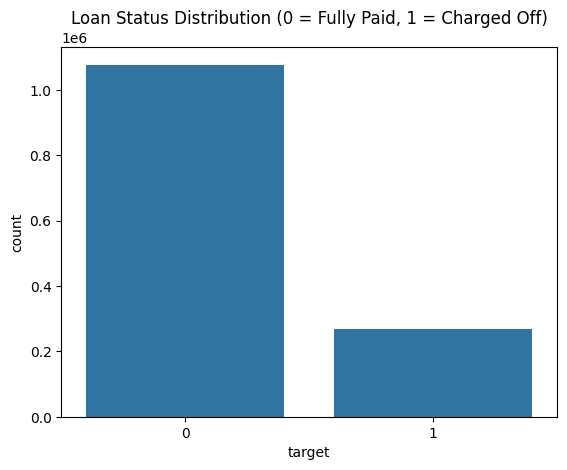

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df1)
plt.title('Loan Status Distribution (0 = Fully Paid, 1 = Charged Off)')
plt.show()


In [9]:
emp_length_mapping = {
    '10+ years': 10,
    '9 years': 9,
    '8 years': 8,
    '7 years': 7,
    '6 years': 6,
    '5 years': 5,
    '4 years': 4,
    '3 years': 3,
    '2 years': 2,
    '1 year': 1,
    '< 1 year': 0.5,
    'n/a': 0
}

df1['emp_length_int'] = df1['emp_length'].map(emp_length_mapping)
df1.head().transpose()


,0,1,2,4,5
id,68407277,68355089,68341763,68476807,68426831
member_id,NaN,NaN,NaN,NaN,NaN
loan_amnt,3600.0,24700.0,20000.0,10400.0,11950.0
funded_amnt,3600.0,24700.0,20000.0,10400.0,11950.0
funded_amnt_inv,3600.0,24700.0,20000.0,10400.0,11950.0
...,...,...,...,...,...
settlement_percentage,NaN,NaN,NaN,NaN,NaN
settlement_term,NaN,NaN,NaN,NaN,NaN
target,0,0,0,0,0
l_condition,Good Loan,Good Loan,Good Loan,Good Loan,Good Loan


In [10]:
state_to_region = {
    'CA': 'West', 'OR': 'West', 'UT': 'West', 'WA': 'West', 'CO': 'West',
    'NV': 'West', 'AK': 'West', 'MT': 'West', 'HI': 'West', 'WY': 'West', 'ID': 'West',
    'AZ': 'SouthWest', 'TX': 'SouthWest', 'NM': 'SouthWest', 'OK': 'SouthWest',
    'GA': 'SouthEast', 'NC': 'SouthEast', 'VA': 'SouthEast', 'FL': 'SouthEast', 'KY': 'SouthEast',
    'SC': 'SouthEast', 'LA': 'SouthEast', 'AL': 'SouthEast', 'WV': 'SouthEast', 'DC': 'SouthEast',
    'AR': 'SouthEast', 'DE': 'SouthEast', 'MS': 'SouthEast', 'TN': 'SouthEast',
    'IL': 'MidWest', 'MO': 'MidWest', 'MN': 'MidWest', 'OH': 'MidWest', 'WI': 'MidWest',
    'KS': 'MidWest', 'MI': 'MidWest', 'SD': 'MidWest', 'IA': 'MidWest', 'NE': 'MidWest',
    'IN': 'MidWest', 'ND': 'MidWest',
    'CT': 'NorthEast', 'NY': 'NorthEast', 'PA': 'NorthEast', 'NJ': 'NorthEast', 'RI': 'NorthEast',
    'MA': 'NorthEast', 'MD': 'NorthEast', 'VT': 'NorthEast', 'NH': 'NorthEast', 'ME': 'NorthEast'
}
df1['region'] = df1['addr_state'].map(state_to_region)
df1.head().transpose()

,0,1,2,4,5
id,68407277,68355089,68341763,68476807,68426831
member_id,NaN,NaN,NaN,NaN,NaN
loan_amnt,3600.0,24700.0,20000.0,10400.0,11950.0
funded_amnt,3600.0,24700.0,20000.0,10400.0,11950.0
funded_amnt_inv,3600.0,24700.0,20000.0,10400.0,11950.0
...,...,...,...,...,...
settlement_term,NaN,NaN,NaN,NaN,NaN
target,0,0,0,0,0
l_condition,Good Loan,Good Loan,Good Loan,Good Loan,Good Loan
emp_length_int,10.0,10.0,10.0,3.0,4.0


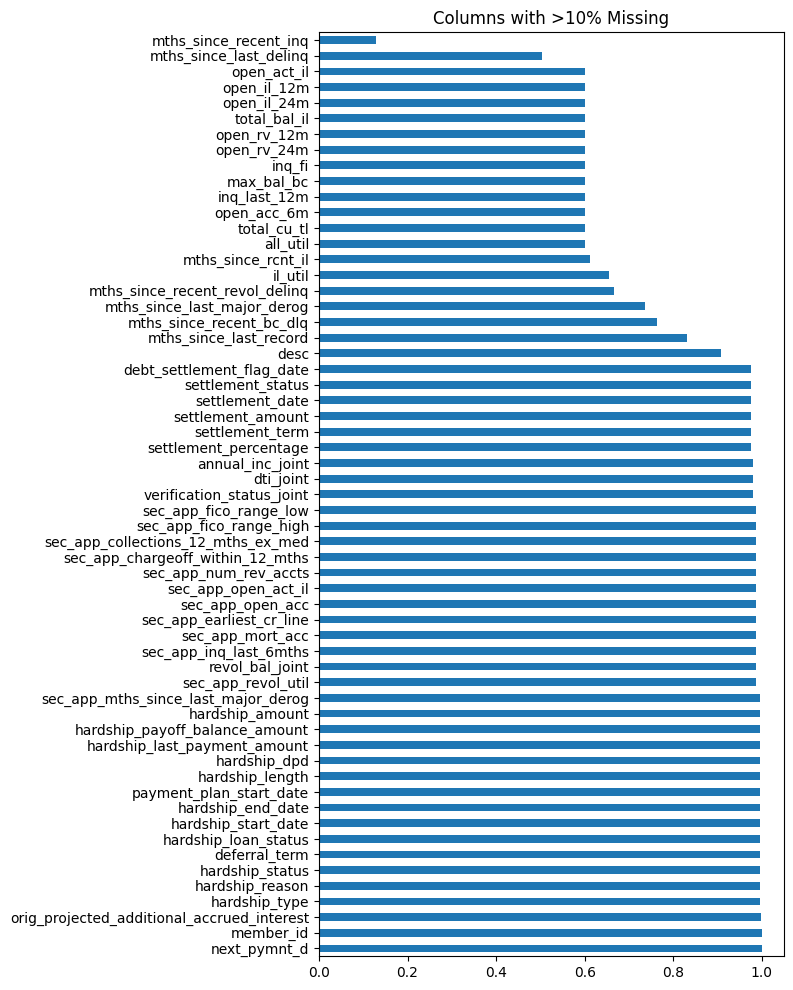

In [11]:
missing = df1.isnull().mean().sort_values(ascending=False)
missing[missing > 0.1].plot(kind='barh', figsize=(6, 12))
plt.title("Columns with >10% Missing")
plt.show()


In [12]:
df1.to_csv("prelim.csv")

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Copy original DataFrame
EDA_df = df1.copy()

# Identify columns
EDA_cat_columns = EDA_df.select_dtypes(include=['object']).columns.tolist()
EDA_num_columns = EDA_df.select_dtypes(exclude=['object']).columns.tolist()

# Filter categorical columns with manageable cardinality
filtered_cat_columns = [col for col in EDA_cat_columns if EDA_df[col].nunique() <= 50]


In [14]:
def plot_categorical_vs_target(dataframe, cat_var, target='l_condition'):
    plt.figure(figsize=(8, 4))
    sns.countplot(x=cat_var, hue=target, data=dataframe)
    plt.title(f'{cat_var} vs {target}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

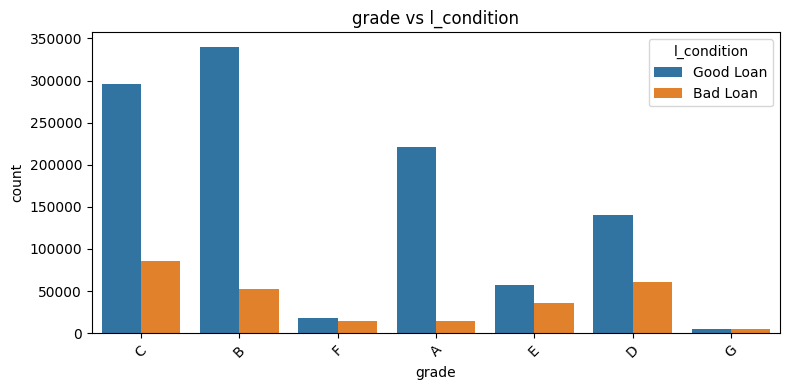

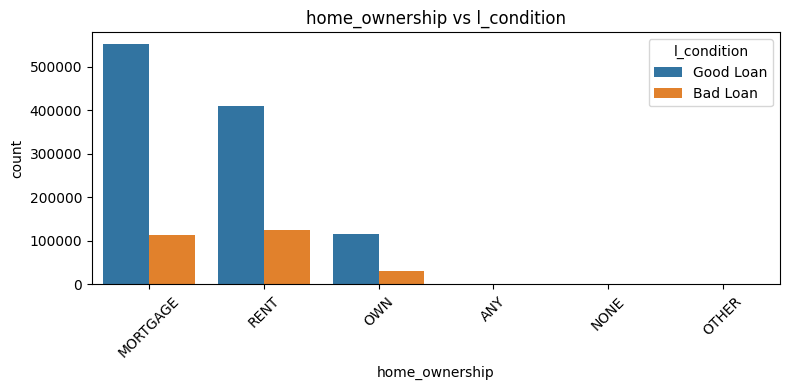

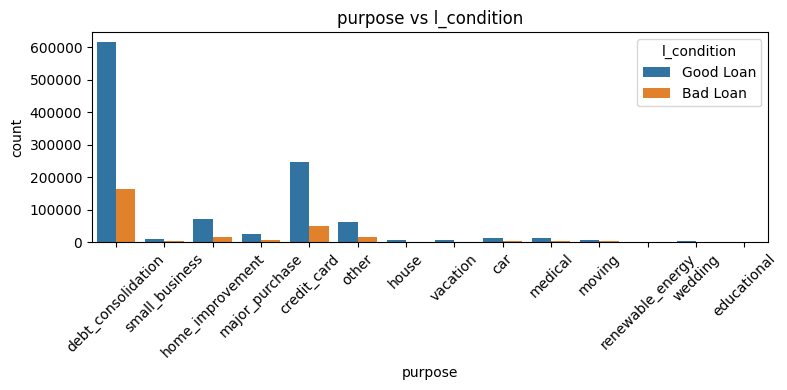

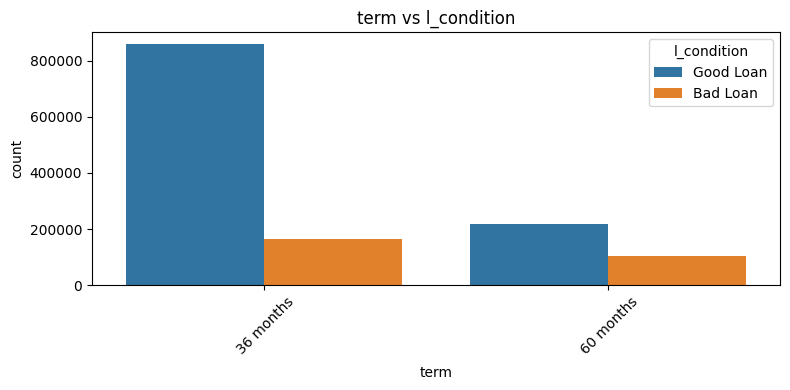

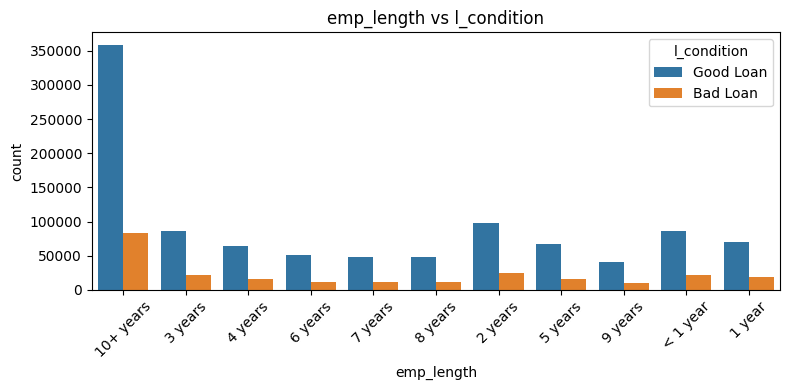

In [15]:
for cat in ['grade', 'home_ownership', 'purpose', 'term', 'emp_length']:
    if cat in EDA_df.columns:
        plot_categorical_vs_target(EDA_df, cat)

In [24]:
def plot_numerical_vs_target(dataframe, num_var, target='l_condition'):
    plt.figure(figsize=(8, 4))
    sns.violinplot(x=target, y=num_var, data=dataframe)
    plt.title(f'{num_var} distribution by {target}')
    plt.tight_layout()
    plt.show()


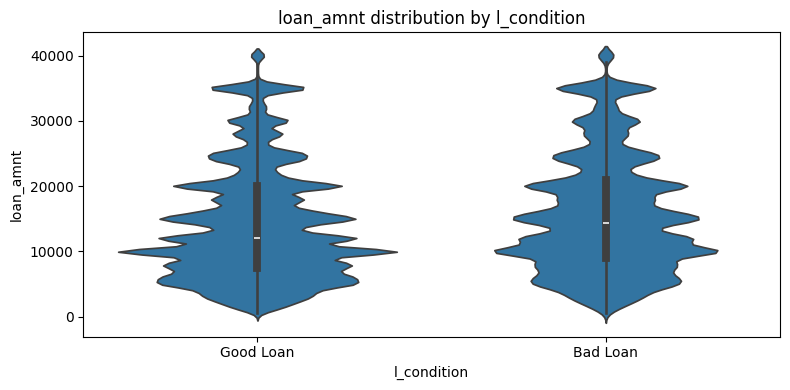

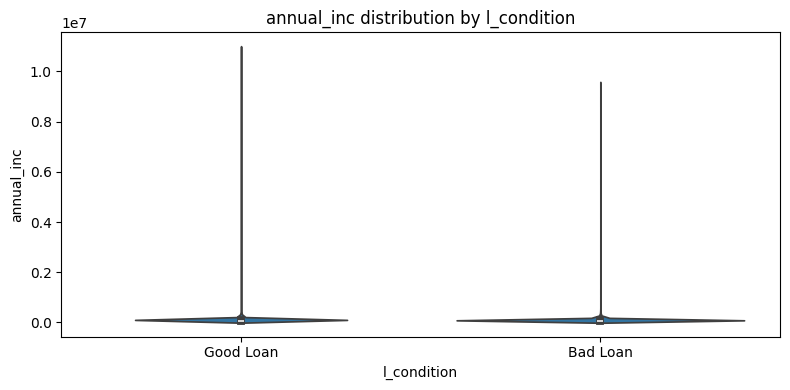

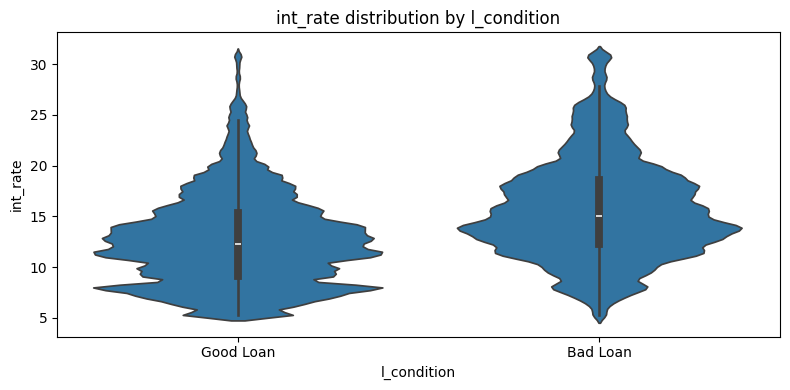

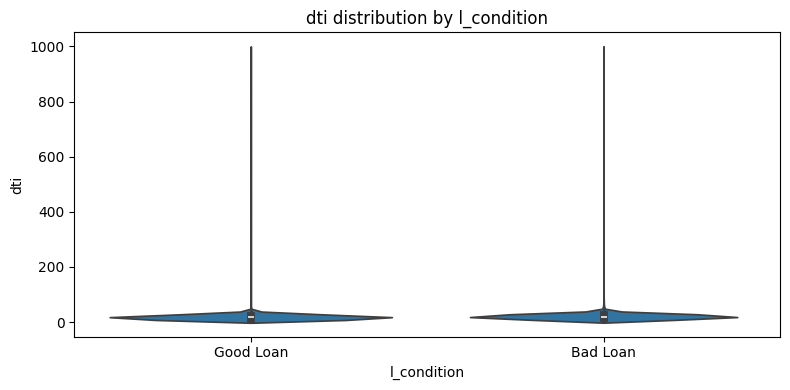

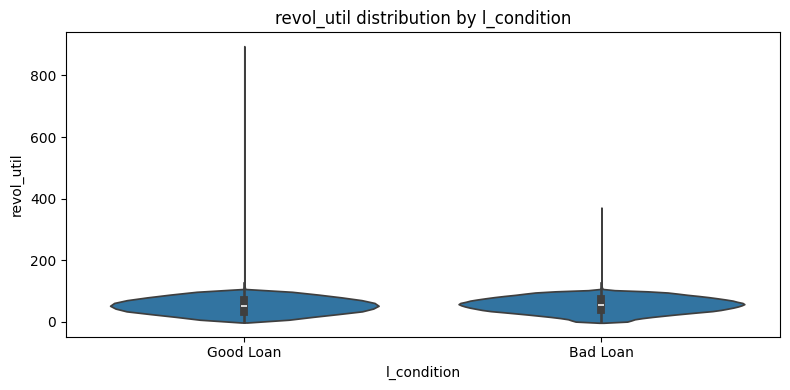

In [25]:
for num in ['loan_amnt', 'annual_inc', 'int_rate', 'dti', 'revol_util']:
    if num in EDA_df.columns:
        plot_numerical_vs_target(EDA_df, num)

In [16]:
pd.value_counts(df1.loan_status).to_frame().reset_index()

C:\Users\siddh\AppData\Local\Temp\ipykernel_41456\626588692.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df1.loan_status).to_frame().reset_index()


,loan_status,count
0,Fully Paid,1076751
1,Charged Off,268559


In [17]:
threshold = 0.7
missing = df1.isnull().mean()
cols_to_drop = missing[missing > threshold].index.tolist()
df1.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} columns with >70% missing values.")


Dropped 42 columns with >70% missing values.


In [19]:
drop_cols = ['id', 'url', 'title', 'emp_title', 'zip_code']
df1.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)
df1

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,target,l_condition,emp_length_int,region
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,7746.0,2400.0,13734.0,N,Cash,N,0,Good Loan,10.0,NorthEast
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,39475.0,79300.0,24667.0,N,Cash,N,0,Good Loan,10.0,MidWest
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,18696.0,6200.0,14877.0,N,Cash,N,0,Good Loan,10.0,MidWest
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,95768.0,20300.0,88097.0,N,Cash,N,0,Good Loan,3.0,NorthEast
5,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,...,12798.0,9400.0,4000.0,N,Cash,N,0,Good Loan,4.0,SouthEast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,5 years,OWN,...,54349.0,13100.0,77756.0,N,Cash,N,0,Good Loan,5.0,SouthWest
2260690,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,9 years,MORTGAGE,...,148305.0,56500.0,95702.0,N,Cash,N,0,Good Loan,9.0,West
2260691,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,3 years,MORTGAGE,...,122872.0,15800.0,23879.0,N,Cash,N,1,Bad Loan,3.0,SouthWest
2260692,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,10+ years,RENT,...,65797.0,10100.0,73473.0,N,Cash,N,0,Good Loan,10.0,SouthEast


In [20]:
missing_summary = df1.isnull().mean()
for col, pct in missing_summary.items():
    if pct > 0:
        print(f"{col:40s} --> {pct:.1%} missing")

emp_length                               --> 5.8% missing
dti                                      --> 0.0% missing
inq_last_6mths                           --> 0.0% missing
mths_since_last_delinq                   --> 50.5% missing
revol_util                               --> 0.1% missing
last_pymnt_d                             --> 0.2% missing
last_credit_pull_d                       --> 0.0% missing
collections_12_mths_ex_med               --> 0.0% missing
tot_coll_amt                             --> 5.0% missing
tot_cur_bal                              --> 5.0% missing
open_acc_6m                              --> 60.0% missing
open_act_il                              --> 60.0% missing
open_il_12m                              --> 60.0% missing
open_il_24m                              --> 60.0% missing
mths_since_rcnt_il                       --> 61.1% missing
total_bal_il                             --> 60.0% missing
il_util                                  --> 65.4% missing
open_r

In [21]:
drop_high_missing = [
    'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'il_util', 'inq_fi', 'all_util',
    'total_bal_il', 'total_cu_tl', 'inq_last_12m', 'mths_since_recent_revol_delinq',
    'mths_since_last_delinq', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc'
]
df1.drop(columns=[col for col in drop_high_missing if col in df.columns], inplace=True)
df1

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,target,l_condition,emp_length_int,region
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,7746.0,2400.0,13734.0,N,Cash,N,0,Good Loan,10.0,NorthEast
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,39475.0,79300.0,24667.0,N,Cash,N,0,Good Loan,10.0,MidWest
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,18696.0,6200.0,14877.0,N,Cash,N,0,Good Loan,10.0,MidWest
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,95768.0,20300.0,88097.0,N,Cash,N,0,Good Loan,3.0,NorthEast
5,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,...,12798.0,9400.0,4000.0,N,Cash,N,0,Good Loan,4.0,SouthEast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,5 years,OWN,...,54349.0,13100.0,77756.0,N,Cash,N,0,Good Loan,5.0,SouthWest
2260690,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,9 years,MORTGAGE,...,148305.0,56500.0,95702.0,N,Cash,N,0,Good Loan,9.0,West
2260691,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,3 years,MORTGAGE,...,122872.0,15800.0,23879.0,N,Cash,N,1,Bad Loan,3.0,SouthWest
2260692,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,10+ years,RENT,...,65797.0,10100.0,73473.0,N,Cash,N,0,Good Loan,10.0,SouthEast


In [22]:
# Columns in df but not in df1 (i.e., dropped columns)
dropped_cols = set(df.columns) - set(df1.columns)
print("🔻 Dropped columns:")
for col in sorted(dropped_cols):
    print("-", col)

# Columns in df1 but not in df (should be none)
added_cols = set(df1.columns) - set(df.columns)
if added_cols:
    print("\n🟢 Added columns:")
    for col in sorted(added_cols):
        print("-", col)
else:
    print("\n✅ No unexpected columns were added.")


🔻 Dropped columns:
- all_util
- annual_inc_joint
- debt_settlement_flag_date
- deferral_term
- desc
- dti_joint
- emp_title
- hardship_amount
- hardship_dpd
- hardship_end_date
- hardship_last_payment_amount
- hardship_length
- hardship_loan_status
- hardship_payoff_balance_amount
- hardship_reason
- hardship_start_date
- hardship_status
- hardship_type
- id
- il_util
- inq_fi
- inq_last_12m
- max_bal_bc
- member_id
- mths_since_last_delinq
- mths_since_last_major_derog
- mths_since_last_record
- mths_since_rcnt_il
- mths_since_recent_bc_dlq
- mths_since_recent_revol_delinq
- next_pymnt_d
- open_acc_6m
- open_act_il
- open_il_12m
- open_il_24m
- open_rv_12m
- open_rv_24m
- orig_projected_additional_accrued_interest
- payment_plan_start_date
- revol_bal_joint
- sec_app_chargeoff_within_12_mths
- sec_app_collections_12_mths_ex_med
- sec_app_earliest_cr_line
- sec_app_fico_range_high
- sec_app_fico_range_low
- sec_app_inq_last_6mths
- sec_app_mort_acc
- sec_app_mths_since_last_major_derog

In [23]:
print(df1.isnull().mean().sort_values(ascending=False))

mths_since_recent_inq    0.129391
num_tl_120dpd_2m         0.087267
mo_sin_old_il_acct       0.078476
emp_length_int           0.058359
emp_length               0.058359
                           ...   
out_prncp                0.000000
initial_list_status      0.000000
total_acc                0.000000
revol_bal                0.000000
region                   0.000000
Length: 92, dtype: float64


In [24]:
pd.set_option('display.max_rows', 150)  # Adjust if needed
missing = df1.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])


mths_since_recent_inq         1.293910e-01
num_tl_120dpd_2m              8.726688e-02
mo_sin_old_il_acct            7.847634e-02
emp_length_int                5.835904e-02
emp_length                    5.835904e-02
pct_tl_nvr_dlq                5.030885e-02
avg_cur_bal                   5.021073e-02
num_rev_accts                 5.019512e-02
mo_sin_rcnt_rev_tl_op         5.019512e-02
mo_sin_old_rev_tl_op          5.019512e-02
num_rev_tl_bal_gt_0           5.019438e-02
num_il_tl                     5.019438e-02
num_op_rev_tl                 5.019438e-02
num_tl_90g_dpd_24m            5.019438e-02
num_bc_tl                     5.019438e-02
num_actv_rev_tl               5.019438e-02
num_actv_bc_tl                5.019438e-02
num_accts_ever_120_pd         5.019438e-02
num_tl_30dpd                  5.019438e-02
num_tl_op_past_12m            5.019438e-02
mo_sin_rcnt_tl                5.019438e-02
tot_coll_amt                  5.019438e-02
total_rev_hi_lim              5.019438e-02
tot_cur_bal

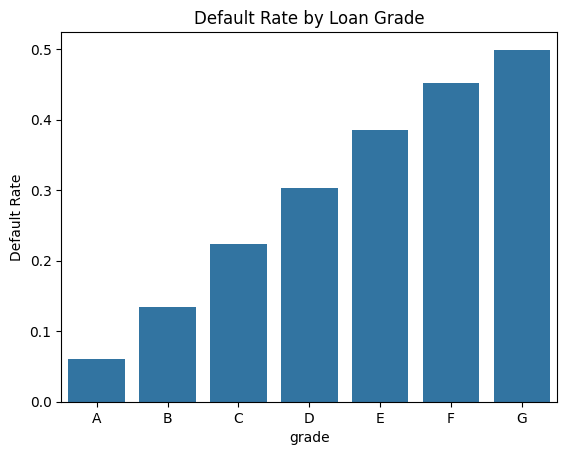

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

grade_default = df1.groupby('grade')['target'].mean().sort_values()
sns.barplot(x=grade_default.index, y=grade_default.values)
plt.title("Default Rate by Loan Grade")
plt.ylabel("Default Rate")
plt.show()


# Interpretation

Default rate rises sharply from Grade A (~6%) to Grade G (~50%)

Grade is a strong risk discriminator — higher grade means safer borrowers.

C:\Users\siddh\AppData\Local\Temp\ipykernel_41456\2161867211.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df1[df1['target'] == 0], x='dti', label='Paid', shade=True)
C:\Users\siddh\AppData\Local\Temp\ipykernel_41456\2161867211.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df1[df1['target'] == 1], x='dti', label='Default', shade=True)


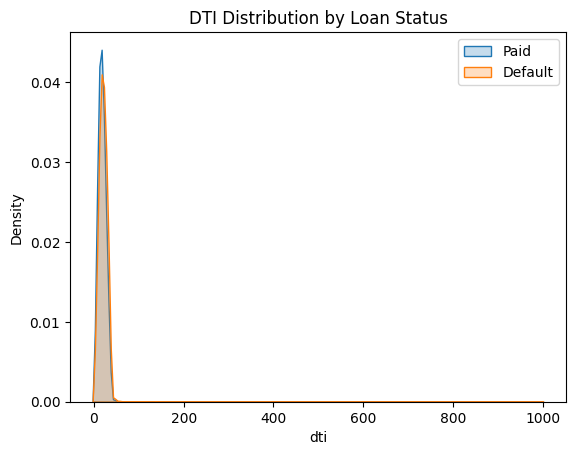

In [27]:
sns.kdeplot(data=df1[df1['target'] == 0], x='dti', label='Paid', shade=True)
sns.kdeplot(data=df1[df1['target'] == 1], x='dti', label='Default', shade=True)
plt.title("DTI Distribution by Loan Status")
plt.legend()
plt.show()


# Interpretation

Distributions are similar, but defaults have a slightly wider DTI range

Very high DTI values (>100) are rare and usually indicate reporting issues


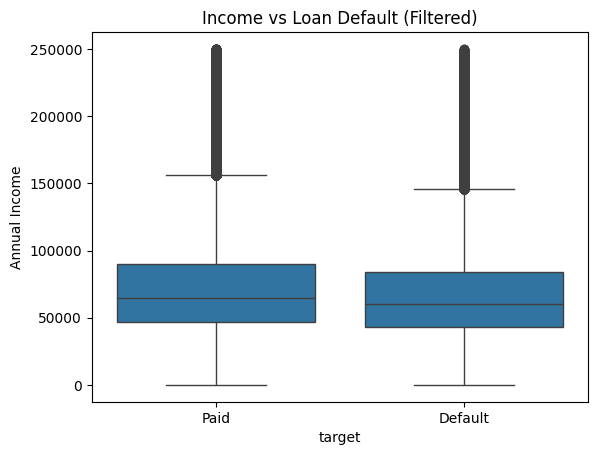

In [29]:
sns.boxplot(data=df1[df1['annual_inc'] < 250000], x='target', y='annual_inc')
plt.title("Income vs Loan Default (Filtered)")
plt.ylabel("Annual Income")
plt.xticks([0, 1], ['Paid', 'Default'])
plt.show()


# Interpretation

Defaulting borrowers have slightly lower median income

But overall distribution overlaps a lot ⇒ income alone is not sufficient


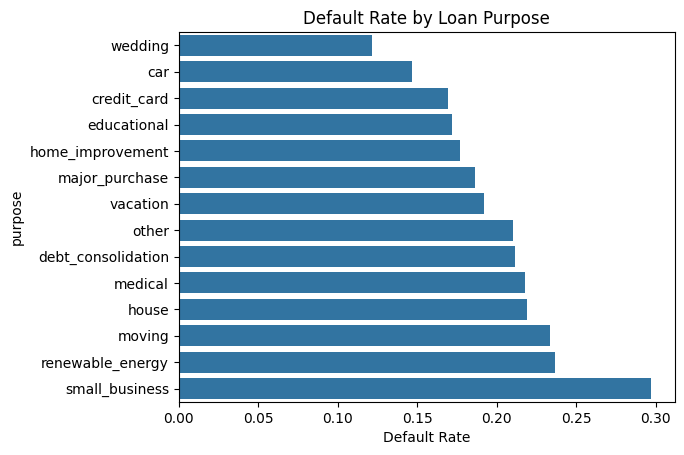

In [30]:
purpose_df = df1.groupby('purpose')['target'].mean().sort_values()
sns.barplot(x=purpose_df.values, y=purpose_df.index)
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate")
plt.show()


# Interpretation

Small business loans have the highest default rate (~30%)

Wedding, car, and credit card loans have the lowest

This is very important, purpose is a strong categorical feature

In [31]:
df1.to_csv("credit_data_clean.csv", index= False)